In [4]:
from misc_utils import hadamard_transform
import numpy as np
import matplotlib.pyplot as plt
from spin_lattices import KagomeLattice
from spin_systems import heisenberg, spin_system, no_symmetries_basis
import pandas as pd
import seaborn as sns
import numpy.typing as npt
import lattice_symmetries as ls
import loguru
from parity import calculate_fourier_transform_matrix
from misc_utils import kronecker_power, rotation_matrix, eigenstate_in_full_basis
from tqdm.auto import tqdm
from ising_sign_reconstruction import custom_signs_hadamard_spread
from spin_systems import zero_sector_basis


In [2]:
lattice = KagomeLattice(2, 4)
system = spin_system(heisenberg(lattice, J2=1), no_symmetries_basis())
system.get_eigenstates(5)

2024-07-29 12:17:35.542 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 5.


(array([-43.03958899, -42.82459918, -42.7457909 , -42.64435572,
        -42.638814  ]),
 array([[ 8.05389473e-19, -2.49302450e-18, -7.80660961e-11,
          3.48078378e-18, -1.38709911e-18],
        [ 8.46720142e-19, -1.09909912e-18,  2.25747994e-09,
          1.30884837e-19, -3.54003866e-20],
        [ 1.10233460e-18, -1.30265820e-19,  3.64694492e-10,
          3.22290089e-19, -9.22179377e-19],
        ...,
        [-3.77048058e-20, -3.57458024e-20,  3.64694492e-10,
         -1.69428748e-18, -1.21716273e-19],
        [-2.09849303e-19,  6.98583289e-19,  2.25747994e-09,
         -2.20793977e-18, -3.62542604e-19],
        [ 1.07998467e-18, -1.06904456e-18, -7.80660935e-11,
          4.95898674e-19,  2.60263507e-19]]))

In [3]:
states = system.basis.states[:20]
new_states = system.basis.states[10:40]
sign_fn = custom_signs_hadamard_spread(
    np.sign(system.get_ground_state_coeffs(states, apply_symmetries=False)), states
)

In [4]:
assert (
    sign_fn(states)
    == np.sign(system.get_ground_state_coeffs(states, apply_symmetries=False))
).all()

In [5]:
assert (
    sign_fn(new_states)[:10]
    == np.sign(system.get_ground_state_coeffs(states[10:], apply_symmetries=False))
).all()

In [8]:
train_size = 1000
states = np.random.choice(
    system.basis.states, p=system.ground_state**2, size=train_size, replace=False
)
test_states = np.random.choice(
    system.basis.states, p=system.ground_state**2, size=10000, replace=False
)
sign_fn = custom_signs_hadamard_spread(
    np.sign(system.get_ground_state_coeffs(states, apply_symmetries=False)), states
)
(sign_fn(test_states) == np.sign(
    system.get_ground_state_coeffs(test_states, apply_symmetries=False)
)).mean()

0.9216

In [26]:
states

array([ 3550563,  1936794, 15820084, ...,  7425393, 14244037, 11679338],
      dtype=uint64)

In [28]:
np.searchsorted([2, 4, 7], [7])

array([2])

In [41]:
np.searchsorted(states, 14856540)

9375

In [42]:
states

array([ 3550563,  1936794, 15820084, ...,  7425393, 14244037, 11679338],
      dtype=uint64)

In [38]:
contained[3]

14856540

In [37]:
np.searchsorted(states, contained)

array([6851, 4018, 3015, ...,  414, 9739, 3425])

In [34]:
np.where(np.searchsorted(states, contained) == 10000)

(array([   3,   14,   18,   35,  110,  129,  150,  153,  164,  183,  216,
         223,  230,  235,  249,  273,  277,  296,  323,  324,  329,  370,
         376,  399,  433,  440,  447,  518,  577,  610,  616,  658,  702,
         705,  727,  778,  792,  855,  870,  899,  908,  923,  924,  928,
         954,  998, 1012, 1042, 1057, 1063, 1128, 1131, 1257, 1278, 1281,
        1289, 1314, 1318, 1341, 1361, 1367, 1404, 1422, 1478, 1496, 1519,
        1568, 1584, 1620, 1629, 1645, 1653, 1661, 1734, 1738, 1776, 1823,
        1836, 1853, 1877, 1912, 1923, 1948, 2002, 2039, 2080, 2097, 2124]),)

In [22]:
def how_many_terms_to_pct(gs_full: npt.NDArray, pct: float) -> int:
    gs_full = gs_full / np.linalg.norm(gs_full)
    cum_weight = np.cumsum(np.sort(gs_full ** 2)[::-1])
    return (cum_weight < pct).sum() + 1

In [30]:
out = []
for J2 in tqdm(np.linspace(0, 1, 11)):
    lattice = KagomeLattice(2, 4)
    system = spin_system(heisenberg(lattice, J2=J2), no_symmetries_basis())

    gs_full = eigenstate_in_full_basis(system.ground_state, system.basis)
    gs_full_hadamard = hadamard_transform(np.sign(gs_full))
    gs_full_hadamard_hadamard = hadamard_transform(np.sign(gs_full_hadamard))
    out.append(
        {
            "J2": J2,
            "terms_gs": how_many_terms_to_pct(gs_full, 0.2),
            "terms_sign_hadamard": how_many_terms_to_pct(gs_full_hadamard, 0.2),
            "terms_sign_hadamard_hadamard": how_many_terms_to_pct(
                gs_full_hadamard_hadamard, 0.2
            ),
            "overlap_hh": (
                np.sign(gs_full_hadamard_hadamard) * np.sign(gs_full) * gs_full**2
            ).sum()
            / (gs_full ** 2).sum(),
        }
    )

  0%|          | 0/11 [00:00<?, ?it/s]

2024-07-25 13:17:24.105 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.
2024-07-25 13:17:24.201 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2024-07-25 13:17:24.261 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2024-07-25 13:17:24.431 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2024-07-25 13:17:24.539 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2024-07-25 13:17:24.616 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2024-07-25 13:17:24.683 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2024-07-25 13:17:24.747 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2024-07-25 13:17:24.821 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2024-07-25 13:17:24.893 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 9.0 of 24.0
2024-0

[1.8078757e-04 3.6157514e-04 5.4236271e-04 ... 1.0000000e+00 1.0000000e+00
 1.0000000e+00]
[0.16118026 0.32236052 0.3226652  ... 1.         1.         1.        ]
[1.19209290e-07 2.38418579e-07 3.57627869e-07 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]


2024-07-25 13:17:29.577 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.
2024-07-25 13:17:29.668 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2024-07-25 13:17:29.727 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2024-07-25 13:17:29.900 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2024-07-25 13:17:30.004 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2024-07-25 13:17:30.081 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2024-07-25 13:17:30.149 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2024-07-25 13:17:30.214 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2024-07-25 13:17:30.289 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2024-07-25 13:17:30.361 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 9.0 of 24.0
2024-0

[1.89449528e-04 3.78899056e-04 5.68348584e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
[0.16118026 0.32236052 0.3226652  ... 1.         1.         1.        ]
[1.19209290e-07 2.38418579e-07 3.57627869e-07 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]


...

[1.26647007e-04 2.53294013e-04 3.79941020e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
[1.13789426e-04 2.27578852e-04 3.41368278e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
[1.78898176e-04 3.50499541e-04 5.12227913e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]


2024-07-25 13:18:17.406 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.
2024-07-25 13:18:17.506 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2024-07-25 13:18:17.564 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2024-07-25 13:18:17.729 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2024-07-25 13:18:17.833 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2024-07-25 13:18:17.911 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2024-07-25 13:18:17.978 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2024-07-25 13:18:18.043 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2024-07-25 13:18:18.117 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2024-07-25 13:18:18.208 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 9.0 of 24.0
2024-0

[1.19178141e-04 2.38356281e-04 3.57534422e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
[1.04097414e-04 2.08194829e-04 3.12292243e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
[2.39100515e-04 4.74513971e-04 7.07883346e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]


2024-07-25 13:18:23.697 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.
2024-07-25 13:18:23.790 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2024-07-25 13:18:23.849 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2024-07-25 13:18:24.014 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2024-07-25 13:18:24.118 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2024-07-25 13:18:24.196 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2024-07-25 13:18:24.264 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2024-07-25 13:18:24.329 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2024-07-25 13:18:24.404 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2024-07-25 13:18:24.476 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 9.0 of 24.0
2024-0

[1.07480390e-04 2.14960781e-04 3.22441171e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
[5.94591650e-05 1.18918330e-04 1.75957321e-04 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
[9.09191209e-06 1.80263543e-05 2.68103542e-05 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]


In [9]:
lattice = KagomeLattice(2, 4)
J2 = 0
system = spin_system(heisenberg(lattice, J2=J2), no_symmetries_basis())
gs_full = eigenstate_in_full_basis(system.ground_state, system.basis)
gs_full_hadamard = hadamard_transform(np.sign(gs_full))

2024-07-25 12:57:23.142 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.
2024-07-25 12:57:23.233 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2024-07-25 12:57:23.291 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2024-07-25 12:57:23.453 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2024-07-25 12:57:23.556 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2024-07-25 12:57:23.633 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2024-07-25 12:57:23.700 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2024-07-25 12:57:23.763 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2024-07-25 12:57:23.838 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2024-07-25 12:57:23.910 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 9.0 of 24.0
2024-0

<Axes: xlabel='J2'>

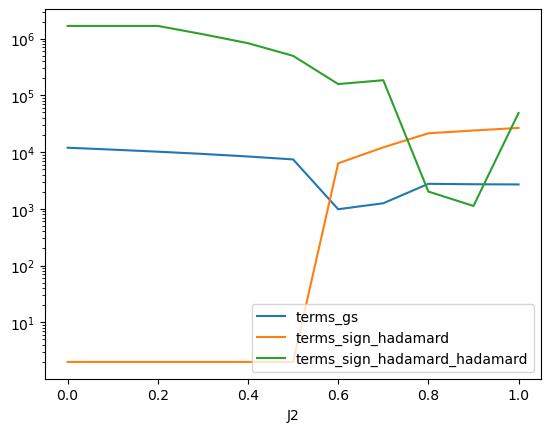

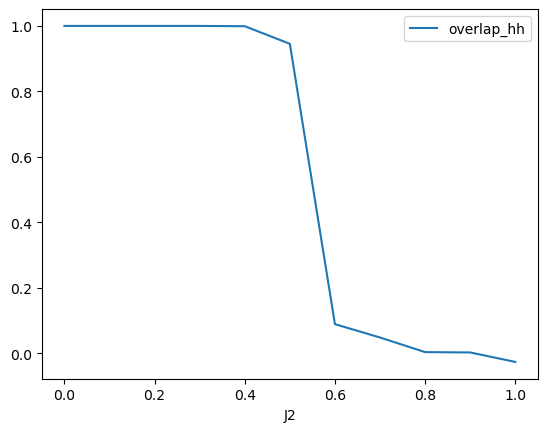

In [34]:
pd.DataFrame(out).plot(
    x="J2", y=["terms_gs", "terms_sign_hadamard", "terms_sign_hadamard_hadamard"]
).set(yscale="log")
pd.DataFrame(out).plot(
    x="J2", y="overlap_hh"
)


In [13]:
noisy_overlaps = []
for noise_level in np.exp(np.linspace(-30, np.log(2 * np.max(system.ground_state)))):
    noisy_ground_state = system.ground_state + np.random.uniform(
        -noise_level, noise_level, system.ground_state.shape
    )
    noisy_ground_state /= np.linalg.norm(noisy_ground_state)
    sign_overlap = np.abs(
        (
            np.sign(system.ground_state)
            * np.sign(noisy_ground_state)
            * system.ground_state**2
        ).sum()
        / (system.ground_state**2).sum()
    )
    accuracy = (np.sign(system.ground_state) == np.sign(noisy_ground_state)).mean()
    noisy_overlaps.append(
        {"noise_level": noise_level, "sign_overlap": sign_overlap, "accuracy": accuracy}
    )

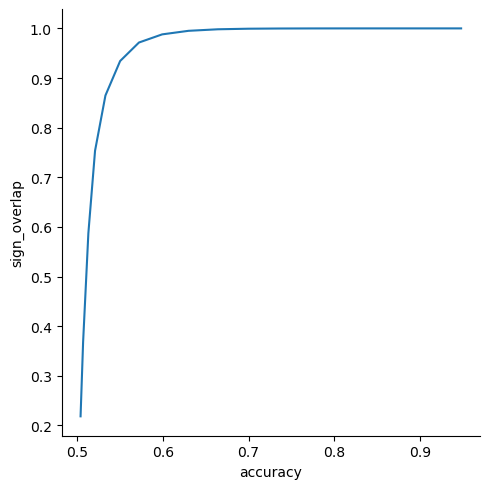

In [14]:
sns.relplot(pd.DataFrame(noisy_overlaps), x="accuracy", y="sign_overlap", kind='line')

In [88]:
def evaluate_hadamard_spreading(
    wavefunction: npt.NDArray[np.float64],
    sample_sizes: npt.NDArray[np.int64],
    sample_power: float,
):
    out = []
    number_spins = int(np.log2(len(wavefunction)))

    for sample_size in sample_sizes:
        sample_size = max(int(sample_size), 1)
        if sample_power == np.inf:
            sample = np.argsort(np.abs(wavefunction))[-sample_size:]
        else:
            sample = np.random.choice(
                np.arange(2**number_spins),
                size=sample_size,
                replace=False,
                p=np.abs(wavefunction) ** sample_power
                / (np.abs(wavefunction) ** sample_power).sum(),
            )

        gs_sampled = np.zeros(2**number_spins)
        gs_sampled[sample] = wavefunction[sample].copy()

        gs_test = wavefunction.copy()
        gs_test[sample] = 0

        gs_sampled_hadamard = hadamard_transform(np.sign(gs_sampled))

        not_sample = np.setdiff1d(np.arange(2**number_spins), sample)

        out.append(
            {
                "sample_size": sample_size,
                "eps_train": sample_size / (np.abs(wavefunction) > 1e-12).sum(),
                "sample_power": sample_power,
                "accuracy_test": (
                    (
                        np.sign(gs_sampled_hadamard[not_sample])
                        * np.sign(gs_test[not_sample])
                    ).mean()
                    + 1
                )
                / 2,
                # "overlap_test": np.abs(gs_truncated_test @ gs_truncated_hadamard)
                # / np.linalg.norm(gs_truncated_test)
                # / np.linalg.norm(gs_truncated_hadamard),
                "sign_overlap_test": (
                    np.sign(gs_sampled_hadamard[not_sample])
                    * np.sign(gs_test[not_sample])
                    * gs_test[not_sample] ** 2
                ).sum()
                / (gs_test[not_sample] ** 2).sum(),
            }
        )
    return pd.DataFrame(out)


# np.allclose(hadamard_transform(gs), gs)

In [89]:
lattice = KagomeLattice(2, 4)
system = spin_system(heisenberg(lattice, J2=1), no_symmetries_basis())
system.get_eigenstates(5)

(array([-43.03958899, -42.82459918, -42.7457909 , -42.64435572,
        -42.638814  ]),
 array([[ 8.05389473e-19, -2.49302450e-18, -7.80660961e-11,
          3.48078378e-18, -1.38709911e-18],
        [ 8.46720142e-19, -1.09909912e-18,  2.25747994e-09,
          1.30884837e-19, -3.54003866e-20],
        [ 1.10233460e-18, -1.30265820e-19,  3.64694492e-10,
          3.22290089e-19, -9.22179377e-19],
        ...,
        [-3.77048058e-20, -3.57458024e-20,  3.64694492e-10,
         -1.69428748e-18, -1.21716273e-19],
        [-2.09849303e-19,  6.98583289e-19,  2.25747994e-09,
         -2.20793977e-18, -3.62542604e-19],
        [ 1.07998467e-18, -1.06904456e-18, -7.80660935e-11,
          4.95898674e-19,  2.60263507e-19]]))

In [17]:
loguru.logger.remove()

sample_sizes = np.exp(np.linspace(np.log(1), np.log(10**6), 30))
evaluations = []
for i, eigenstate in enumerate(system.eigenstates.T[:1]):
    print(f"eigenstate {i}")
    for sample_power in [np.inf, 1, 2, 4]:
        print(f"sample_power {sample_power}")
        evaluations.append(
            evaluate_hadamard_spreading(
                eigenstate_in_full_basis(eigenstate, system.basis),
                sample_sizes=sample_sizes,
                sample_power=sample_power,
            ).assign(eigenstate=i)
        )

eigenstate 0
sample_power inf
sample_power 1
sample_power 2
sample_power 4


In [19]:
pd.concat(evaluations).columns

Index(['sample_size', 'eps_train', 'sample_power', 'accuracy_test',
       'sign_overlap_test', 'eigenstate'],
      dtype='object')

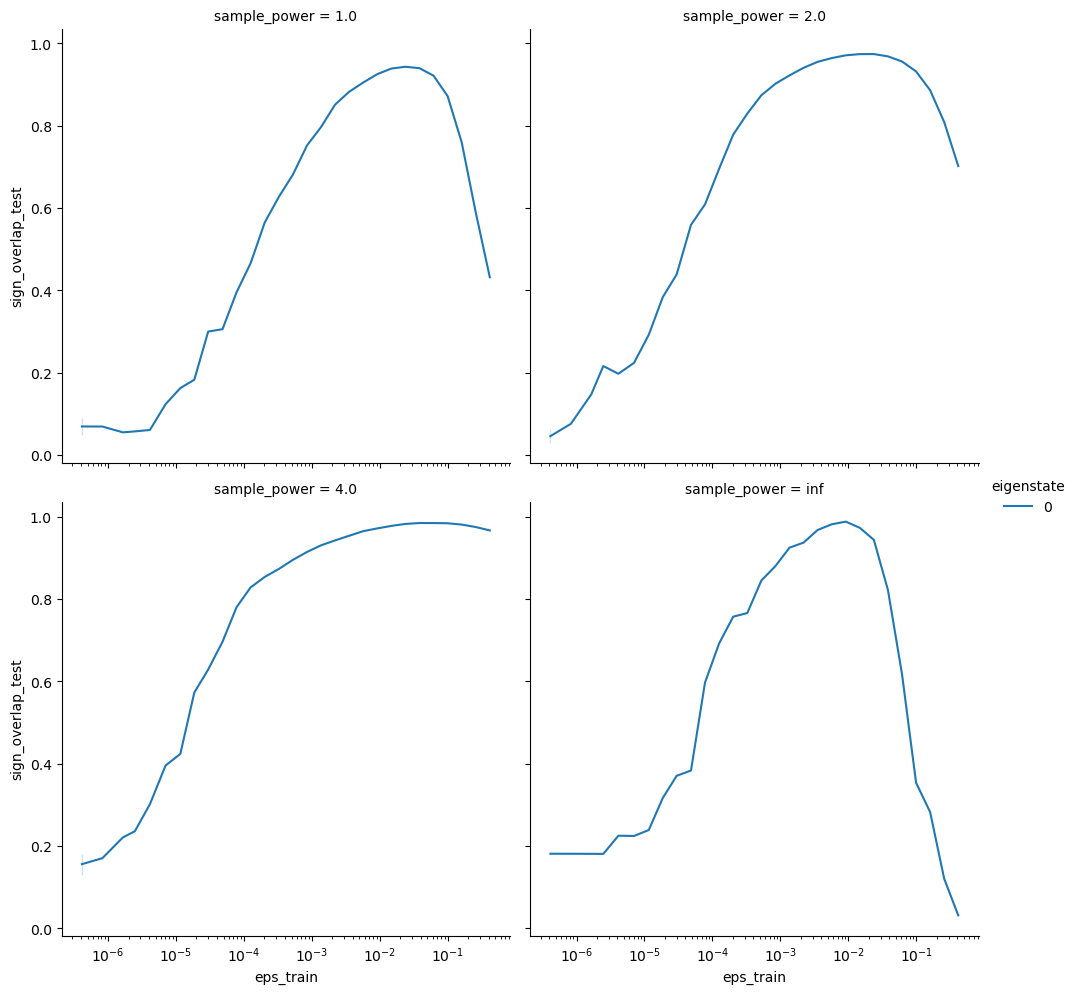

In [23]:
sns.relplot(
    pd.concat(evaluations)
    .astype({"eigenstate": "category"})
    .assign(accuracy_test=lambda x: np.maximum(x.accuracy_test, 1 - x.accuracy_test)),
    x="eps_train",
    y="sign_overlap_test",
    hue="eigenstate",
    kind="line",
    col="sample_power",
    col_wrap=2,
)
plt.xscale("log")

In [7]:
def truncate_and_hadamard(gs, keep):
    gs_truncated = gs.copy()
    largest_terms = np.argsort(np.abs(gs))[:-keep]
    gs_truncated[largest_terms] = 0
    return hadamard_transform(np.sign(gs_truncated)), largest_terms

In [9]:
out = []
gs_truncated_hadamards = []
for keep in [int(10**i) for i in np.linspace(3, 5, 20)]:
    gs_truncated_hadamard, largest_terms = truncate_and_hadamard(gs, keep)

    gs_truncated_test = np.zeros_like(gs)
    gs_truncated_test[largest_terms] = gs[largest_terms]
    out.append(
        {
            "keep": keep,
            "iteration": 0,
            # "accuracy": (np.sign(gs_truncated_hadamard) == np.sign(gs)).mean(),
            "overlap_test": np.abs(gs_truncated_test @ gs_truncated_hadamard)
            / np.linalg.norm(gs_truncated_test)
            / np.linalg.norm(gs_truncated_hadamard),
        }
    )
    for iteration in range(1, 2):
        gs_truncated_hadamard, _ = truncate_and_hadamard(gs_truncated_hadamard, keep)
        out.append(
            {
                "keep": keep,
                "iteration": iteration,
                # "accuracy": (np.sign(gs_truncated_hadamard) == np.sign(gs)).mean(),
                "overlap_test": np.abs(gs_truncated_test @ gs_truncated_hadamard)
                / np.linalg.norm(gs_truncated_test)
                / np.linalg.norm(gs_truncated_hadamard),
                "sign_overlap_test": (
                    np.sign(gs_truncated_hadamard)
                    * np.sign(gs_truncated_test)
                    * gs_truncated_test**2
                ).sum()
                / (gs_truncated_test ** 2).sum(),
            }
        )
# np.allclose(hadamard_transform(gs), gs)

2024-07-09 16:13:31.004 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 24.0
2024-07-09 16:13:31.063 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 24.0
2024-07-09 16:13:31.233 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 24.0
2024-07-09 16:13:31.337 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 24.0
2024-07-09 16:13:31.414 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 24.0
2024-07-09 16:13:31.481 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 24.0
2024-07-09 16:13:31.546 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 24.0
2024-07-09 16:13:31.620 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 24.0
2024-07-09 16:13:31.693 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 9.0 of 24.0
2024-07-09 16:13:31.762 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 10.0 of 24.0
2024-07-09 16:13:31.825 | DEBUG    | misc_utils:h

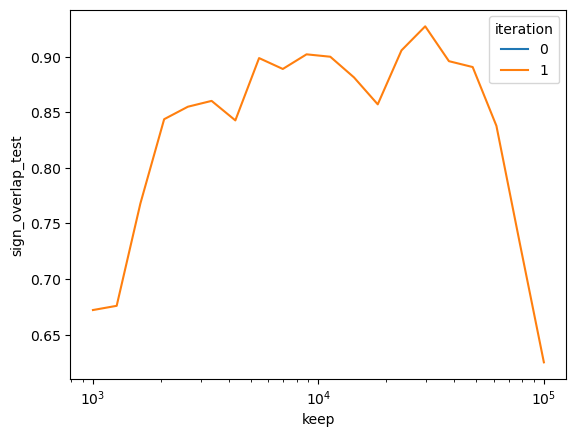

In [10]:
df = pd.DataFrame(out)
sns.lineplot(data=df.astype({'iteration': str}), x='keep', y='sign_overlap_test', hue='iteration')
plt.xscale('log')

In [7]:
def evaluate_hadamard_spreading_test_set(
    wavefunction: npt.NDArray[np.float64],
    basis: ls.Basis,
    sample_size: int,
    sample_power: float,
    test_size: int = 10000,
):
    assert sample_size >= 1

    if sample_power == np.inf:
        sample = np.argsort(np.abs(wavefunction))[-sample_size:]
    else:
        sample = np.random.choice(
            np.arange(len(wavefunction)),
            size=sample_size,
            replace=False,
            p=np.abs(wavefunction) ** sample_power
            / (np.abs(wavefunction) ** sample_power).sum(),
        )

    test_sample = np.random.choice(
        np.setdiff1d(np.arange(len(wavefunction)), sample),
        size=test_size,
        replace=False,
    )
    test_wavefunction = wavefunction[test_sample]

    transform_matrix = calculate_fourier_transform_matrix(
        basis.states[test_sample], basis.states[sample], out_dtype="float64"
    )

    predictions = transform_matrix @ np.sign(wavefunction[sample])

    return {
        "sample_size": sample_size,
        "eps_train": sample_size / (np.abs(wavefunction) > 1e-12).sum(),
        "sample_power": sample_power,
        "test_size": test_size,
        "accuracy_test": (
            (np.sign(test_wavefunction) * np.sign(predictions)).mean() + 1
        )
        / 2,
        # "overlap_test": np.abs(gs_truncated_test @ gs_truncated_hadamard)
        # / np.linalg.norm(gs_truncated_test)
        # / np.linalg.norm(gs_truncated_hadamard),
        "sign_overlap_test": (
            np.sign(predictions) * np.sign(test_wavefunction) * test_wavefunction**2
        ).sum()
        / (test_wavefunction**2).sum(),
        "sign_overlap_with_random": (
            np.sign(predictions)
            * np.sign(np.random.choice(np.sign(test_wavefunction), size=test_size))
            * test_wavefunction**2
        ).sum()
        / (test_wavefunction**2).sum(),
    }

In [13]:
lattice = KagomeLattice(2, 4)
system = spin_system(heisenberg(lattice, J2=1), zero_sector_basis(spin_inversion=None))
wavefunction = system.ground_state
evaluate_hadamard_spreading_test_set(wavefunction, system.basis, 1000, np.inf)

2024-07-29 12:25:07.584 | DEBUG    | spin_systems:_find_cached_eigenstate:191 - Using cached version of eigenvalues / eigenstates up to 1.


{'sample_size': 1000,
 'eps_train': 0.041751910149889354,
 'sample_power': inf,
 'test_size': 10000,
 'accuracy_test': 0.5276,
 'sign_overlap_test': 0.363162096230542,
 'sign_overlap_with_random': 0.03059466892506789}

In [103]:
sample_sizes = np.exp(np.linspace(np.log(1), np.log(10**6), 30)).astype(int)
evaluations = []
for run in range(1):
    for i, eigenstate in enumerate(system.eigenstates.T[:2]):
        for sample_size in sample_sizes:
            print(f"eigenstate {i}, sample_size {sample_size}")
            for sample_power in [np.inf, 0.001, 0.5, 1, 2, 4]:
                print(f"sample_power {sample_power}")
                evaluations.append(
                    evaluate_hadamard_spreading_test_set(
                        wavefunction=eigenstate,
                        basis=system.basis,
                        sample_size=sample_size,
                        sample_power=sample_power,
                    ) | dict(eigenstate=i, run=run)
                )

eigenstate 0, sample_size 1
sample_power inf
sample_power 0.001
sample_power 0.5
sample_power 1
sample_power 2
sample_power 4
eigenstate 0, sample_size 1
sample_power inf
sample_power 0.001
sample_power 0.5
sample_power 1
sample_power 2
sample_power 4
eigenstate 0, sample_size 2
sample_power inf
sample_power 0.001
sample_power 0.5
sample_power 1
sample_power 2
sample_power 4
eigenstate 0, sample_size 4
sample_power inf
sample_power 0.001
sample_power 0.5
sample_power 1
sample_power 2
sample_power 4
eigenstate 0, sample_size 6
sample_power inf
sample_power 0.001
sample_power 0.5
sample_power 1
sample_power 2
sample_power 4
eigenstate 0, sample_size 10
sample_power inf
sample_power 0.001
sample_power 0.5
sample_power 1
sample_power 2
sample_power 4
eigenstate 0, sample_size 17
sample_power inf
sample_power 0.001
sample_power 0.5
sample_power 1
sample_power 2
sample_power 4
eigenstate 0, sample_size 28
sample_power inf
sample_power 0.001
sample_power 0.5
sample_power 1
sample_power 2
samp

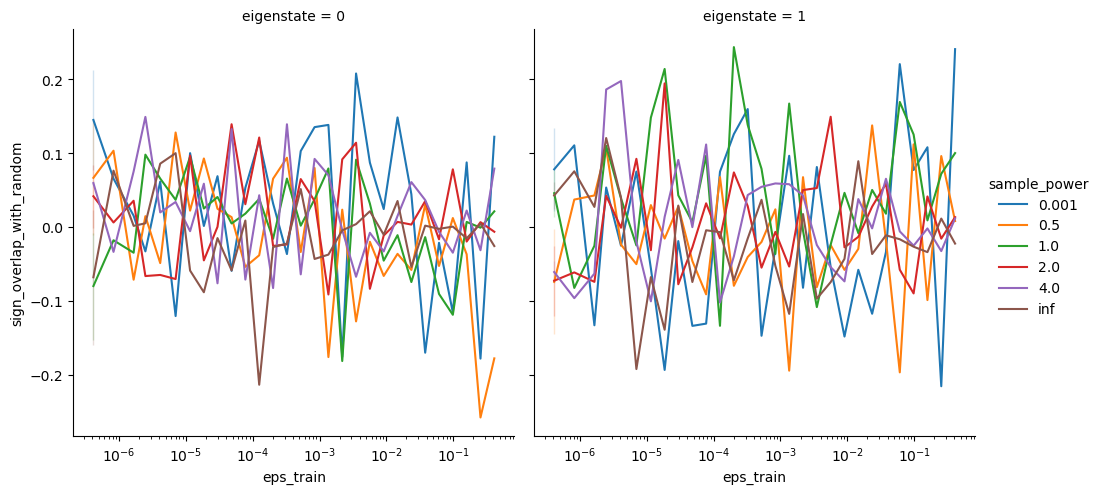

In [105]:
sns.relplot(
    pd.DataFrame(evaluations)
    .astype({"eigenstate": "category", "sample_power": "category"})
    .assign(accuracy_test=lambda x: np.maximum(x.accuracy_test, 1 - x.accuracy_test)),
    x="eps_train",
    y="sign_overlap_with_random",
    #hue="eigenstate",
    kind="line",
    hue="sample_power",
    col="eigenstate",
    col_wrap=2,
)
plt.xscale("log")

In [24]:
ground_state = system.ground_state
shuffled_ground_state = ground_state.copy()
np.random.shuffle(shuffled_ground_state)
shuffled_ground_state *= np.random.choice([-1, 1], len(shuffled_ground_state))
gs_full = eigenstate_in_full_basis(ground_state, system.basis)
shuffled_gs_full = eigenstate_in_full_basis(shuffled_ground_state, system.basis)
hadamard_invariant_wavefunction = (hadamard_transform(shuffled_gs_full) + shuffled_gs_full) / 2

In [26]:
assert np.allclose(hadamard_transform(hadamard_invariant_wavefunction), hadamard_invariant_wavefunction)

In [27]:
loguru.logger.remove()

sample_sizes = np.exp(np.linspace(np.log(1), np.log(10**6), 30))
evaluations = []
for sample_power in [np.inf, 1, 2, 4]:
    print(f"sample_power {sample_power}")
    evaluations.append(
        evaluate_hadamard_spreading(
            hadamard_invariant_wavefunction,
            sample_sizes=sample_sizes,
            sample_power=sample_power,
        )
    )

sample_power inf
sample_power 1
sample_power 2
sample_power 4


In [28]:
pd.concat(evaluations).columns

Index(['sample_size', 'eps_train', 'sample_power', 'accuracy_test',
       'sign_overlap_test'],
      dtype='object')

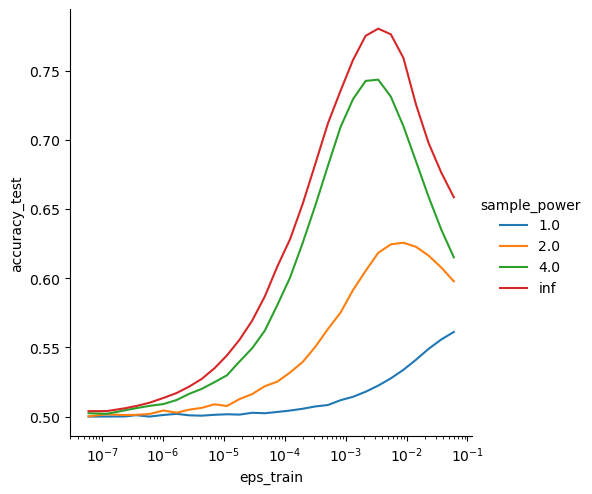

In [33]:
sns.relplot(
    pd.concat(evaluations)
    .astype({"sample_power": "category"})
    .assign(accuracy_test=lambda x: np.maximum(x.accuracy_test, 1 - x.accuracy_test)),
    x="eps_train",
    y="accuracy_test",
    #hue="eigenstate",
    kind="line",
    hue="sample_power",
    #col_wrap=2,
)
plt.xscale("log")

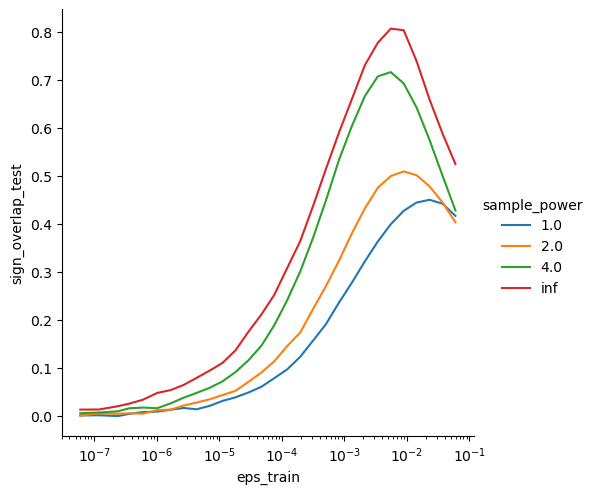

In [34]:
sns.relplot(
    pd.concat(evaluations)
    .astype({"sample_power": "category"})
    .assign(accuracy_test=lambda x: np.maximum(x.accuracy_test, 1 - x.accuracy_test)),
    x="eps_train",
    y="sign_overlap_test",
    #hue="eigenstate",
    kind="line",
    hue="sample_power",
    #col_wrap=2,
)
plt.xscale("log")

In [4]:
from scipy.linalg import hadamard, kron

In [40]:
kron(kron(hadamard(2), hadamard(2)), hadamard(2)) == hadamard(8)

array([[ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True]])

In [46]:
phi = np.pi / 9
r_mat = rotation_matrix(phi)
kron(kron(r_mat, r_mat), r_mat)

array([[ 0.82976947, -0.30201139, -0.30201139,  0.10992316, -0.30201139,
         0.10992316,  0.10992316, -0.04000876],
       [ 0.30201139,  0.82976947, -0.10992316, -0.30201139, -0.10992316,
        -0.30201139,  0.04000876,  0.10992316],
       [ 0.30201139, -0.10992316,  0.82976947, -0.30201139, -0.10992316,
         0.04000876, -0.30201139,  0.10992316],
       [ 0.10992316,  0.30201139,  0.30201139,  0.82976947, -0.04000876,
        -0.10992316, -0.10992316, -0.30201139],
       [ 0.30201139, -0.10992316, -0.10992316,  0.04000876,  0.82976947,
        -0.30201139, -0.30201139,  0.10992316],
       [ 0.10992316,  0.30201139, -0.04000876, -0.10992316,  0.30201139,
         0.82976947, -0.10992316, -0.30201139],
       [ 0.10992316, -0.04000876,  0.30201139, -0.10992316,  0.30201139,
        -0.10992316,  0.82976947, -0.30201139],
       [ 0.04000876,  0.10992316,  0.10992316,  0.30201139,  0.10992316,
         0.30201139,  0.30201139,  0.82976947]])

In [11]:
n = 10
test_x = np.random.uniform(-1, 1, 2**n)
obtained = (kronecker_power(test_x, hadamard(2))) / 2 ** (n / 2)
expected = hadamard_transform(test_x)
assert np.allclose(obtained, expected)

2024-07-23 19:20:34.887 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 1.0 of 10.0
2024-07-23 19:20:34.888 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 2.0 of 10.0
2024-07-23 19:20:34.888 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 3.0 of 10.0
2024-07-23 19:20:34.889 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 4.0 of 10.0
2024-07-23 19:20:34.889 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 5.0 of 10.0
2024-07-23 19:20:34.890 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 6.0 of 10.0
2024-07-23 19:20:34.890 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 7.0 of 10.0
2024-07-23 19:20:34.891 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 8.0 of 10.0
2024-07-23 19:20:34.891 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 9.0 of 10.0
2024-07-23 19:20:34.891 | DEBUG    | misc_utils:hadamard_transform:176 - iteration 10.0 of 10.0


In [22]:
-rotation_matrix(7 * np.pi / 4)

array([[-0.70710678, -0.70710678],
       [ 0.70710678, -0.70710678]])

In [65]:
test_x = np.random.uniform(-1, 1, 2 ** 3)
rot_matrix = rotation_matrix(np.pi / 9)
np.allclose(kronekker_power(test_x, rot_matrix).reshape(-1) * np.sqrt(8), kron(kron(rot_matrix, rot_matrix), rot_matrix) @ test_x)

True

In [90]:
def evaluate_rot_spreading(
    wavefunction: npt.NDArray[np.float64],
    sample_sizes: npt.NDArray[np.int64],
    rot_angle: float,
    sample_power: float,
):
    out = []
    rot_matrix = rotation_matrix(rot_angle)
    number_spins = int(np.log2(len(wavefunction)))

    for sample_size in sample_sizes:
        sample_size = max(int(sample_size), 1)
        if sample_power == np.inf:
            sample = np.argsort(np.abs(wavefunction))[-sample_size:]
        else:
            sample = np.random.choice(
                np.arange(2**number_spins),
                size=sample_size,
                replace=False,
                p=np.abs(wavefunction) ** sample_power
                / (np.abs(wavefunction) ** sample_power).sum(),
            )

        gs_sampled = np.zeros(2**number_spins)
        gs_sampled[sample] = wavefunction[sample].copy()

        gs_test = wavefunction.copy()
        gs_test[sample] = 0

        gs_sampled_rot = kronecker_power(np.sign(gs_sampled), rot_matrix)

        not_sample = np.setdiff1d(np.arange(2**number_spins), sample)

        out.append(
            {
                "sample_size": sample_size,
                "eps_train": sample_size / (np.abs(wavefunction) > 1e-12).sum(),
                "sample_power": sample_power,
                "rot_angle": rot_angle,
                "accuracy_test": (
                    (
                        np.sign(gs_sampled_rot[not_sample])
                        * np.sign(gs_test[not_sample])
                    ).mean()
                    + 1
                )
                / 2,
                # "overlap_test": np.abs(gs_truncated_test @ gs_truncated_hadamard)
                # / np.linalg.norm(gs_truncated_test)
                # / np.linalg.norm(gs_truncated_hadamard),
                "sign_overlap_test": (
                    np.sign(gs_sampled_rot[not_sample])
                    * np.sign(gs_test[not_sample])
                    * gs_test[not_sample] ** 2
                ).sum()
                / (gs_test[not_sample] ** 2).sum(),
                "overlap_test": (gs_sampled_rot[not_sample] * gs_test[not_sample]).sum()
                / np.linalg.norm(gs_sampled_rot[not_sample])
                / np.linalg.norm(gs_test[not_sample]),
            }
        )
    return pd.DataFrame(out)


# np.allclose(hadamard_transform(gs), gs)

In [91]:
np.linspace(0, 1, 9)

array([0.   , 0.125, 0.25 , 0.375, 0.5  , 0.625, 0.75 , 0.875, 1.   ])

In [92]:
loguru.logger.remove()

sample_sizes = np.exp(np.linspace(np.log(10**1), np.log(10**5), 10))
evaluations = []
for angle in np.linspace(0, np.pi / 2, 5):
    print(f"angle {angle}")
    for sample_power in [2]:
        print(f"sample_power {sample_power}")
        evaluations.append(
            evaluate_rot_spreading(
                eigenstate_in_full_basis(eigenstate, system.basis),
                sample_sizes=sample_sizes,
                rot_angle=angle,
                sample_power=sample_power,
            ).assign(eigenstate=i)
        )

angle 0.0
sample_power 2


/tmp/nix-shell.0cm8Ru/ipykernel_1068400/2618502988.py:57: RuntimeWarning: invalid value encountered in scalar divide
  "overlap_test": (gs_sampled_rot[not_sample] * gs_test[not_sample]).sum()


angle 0.39269908169872414
sample_power 2
angle 0.7853981633974483
sample_power 2
angle 1.1780972450961724
sample_power 2
angle 1.5707963267948966
sample_power 2


In [97]:
pd.concat(evaluations)['overlap_test']

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
5         NaN
6         NaN
7         NaN
8         NaN
9         NaN
0    0.010737
1    0.021510
2    0.031190
3    0.058569
4    0.096882
5    0.153594
6    0.238064
7    0.334864
8    0.391897
9    0.350500
0    0.015465
1    0.024020
2    0.042768
3    0.063055
4    0.108833
5    0.173073
6    0.278802
7    0.404643
8    0.474977
9    0.358042
0    0.012770
1    0.026446
2    0.044379
3    0.062416
4    0.111497
5    0.175547
6    0.274371
7    0.378052
8    0.438017
9    0.405294
0    0.016946
1    0.032257
2    0.041754
3    0.062981
4    0.109258
5    0.177132
6    0.269108
7    0.373447
8    0.437948
9    0.502667
Name: overlap_test, dtype: float64

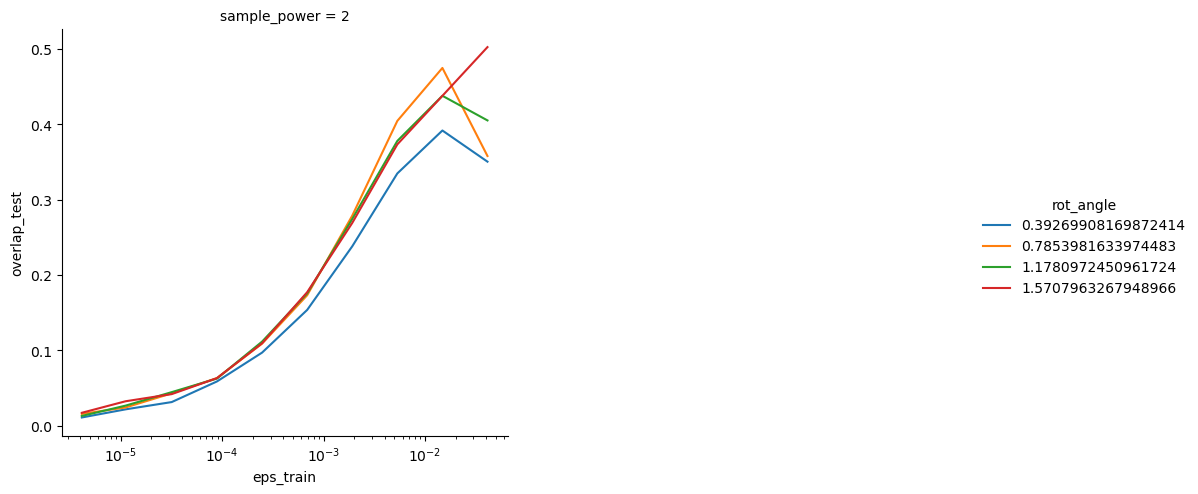

In [98]:
sns.relplot(
    pd.concat(evaluations).dropna()
    .astype({"rot_angle": "category"})
    .assign(accuracy_test=lambda x: np.maximum(x.accuracy_test, 1 - x.accuracy_test)),
    x="eps_train",
    y="overlap_test",
    hue="rot_angle",
    kind="line",
    col="sample_power",
    col_wrap=2,
)
plt.xscale("log")

In [80]:
np.linspace(0, np.pi / 2, 21)[1]

0.07853981633974483

In [107]:
loguru.logger.remove()

sample_sizes = np.array([int((np.abs(eigenstate) > 1e-12).sum() * 0.01)])
evaluations = []
for angle in np.linspace(0, np.pi / 2, 11):
    print(f"angle {angle}")
    for sample_power in [2]:
        print(f"sample_power {sample_power}")
        evaluations.append(
            evaluate_rot_spreading(
                eigenstate_in_full_basis(eigenstate, system.basis),
                sample_sizes=sample_sizes,
                rot_angle=angle,
                sample_power=sample_power,
            ).assign(eigenstate=i)
        )

angle 0.0
sample_power 2


/tmp/nix-shell.0cm8Ru/ipykernel_1068400/2618502988.py:57: RuntimeWarning: invalid value encountered in scalar divide
  "overlap_test": (gs_sampled_rot[not_sample] * gs_test[not_sample]).sum()


angle 0.15707963267948966
sample_power 2
angle 0.3141592653589793
sample_power 2
angle 0.47123889803846897
sample_power 2
angle 0.6283185307179586
sample_power 2
angle 0.7853981633974483
sample_power 2
angle 0.9424777960769379
sample_power 2
angle 1.0995574287564276
sample_power 2
angle 1.2566370614359172
sample_power 2
angle 1.413716694115407
sample_power 2
angle 1.5707963267948966
sample_power 2


([<matplotlib.axis.XTick at 0x154e60d41dd0>,
 [Text(0.0, 0, '0'),
  Text(0.7853981633974483, 0, '$\\pi/4$'),
  Text(1.5707963267948966, 0, '$\\pi/2$')])

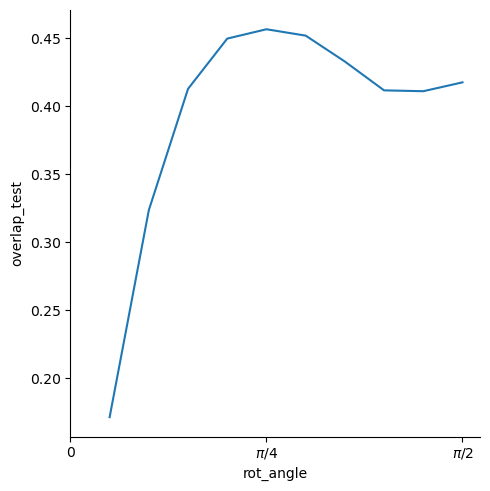

In [111]:
sns.relplot(
    pd.concat(evaluations).dropna()
    #.astype({"rot_angle": "category"})
    .assign(accuracy_test=lambda x: np.maximum(x.accuracy_test, 1 - x.accuracy_test)),
    x="rot_angle",
    y="overlap_test",
    #hue="rot_angle",
    kind="line",
    #col="sample_power",
    #col_wrap=2,
)
# add xticks for pi/4, pi/2
plt.xticks([0, np.pi / 4, np.pi / 2], ['0', r'$\pi/4$', r'$\pi/2$'])
#plt.xscale("log")